In [15]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
from sklearn.metrics import classification_report

import keras
from keras import datasets
from keras import layers
from keras import losses
from keras import metrics
from keras import optimizers

In [16]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [17]:
x_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [18]:
x_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

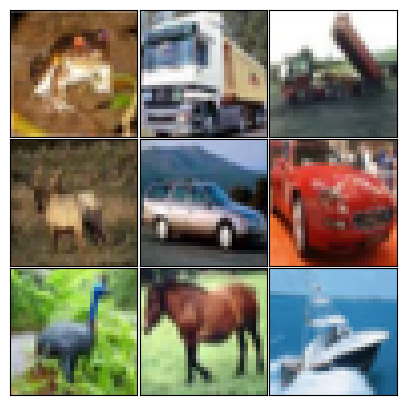

In [19]:
def plot_9_images(images):
    fig, axes = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=True, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.01, wspace=0.01)

    num_images = images.shape[0]
    for i in range(num_images):
        axes.flatten()[i].imshow(images[i], cmap="Greys_r")
        axes.flatten()[i].set_xticks([])
        axes.flatten()[i].set_yticks([])

    fig.show()
    return

plot_9_images(x_train[:9])

In [20]:
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [21]:
x_test.min(), x_test.max()

(np.uint8(0), np.uint8(255))

In [22]:
def minmax_scaling(x, min_val=0, max_val=255):
    x_scaled = (x - min_val) / (max_val)
    return x_scaled

x_train_scaled = minmax_scaling(x_train)
x_test_scaled = minmax_scaling(x_test)

In [23]:
x_train_scaled.min(), x_train_scaled.max()

(np.float64(0.0), np.float64(1.0))

In [24]:
x_test_scaled.min(), x_test_scaled.max()

(np.float64(0.0), np.float64(1.0))

In [25]:
x_train_scaled.shape

(50000, 32, 32, 3)

In [26]:
model = keras.models.Sequential()
model.add(layers.InputLayer(shape=x_train_scaled.shape[1:]))
model.add(layers.Conv2D(128, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(64, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2DTranspose(64, (5, 5), strides=2, activation="relu", padding="same"))
model.add(layers.Conv2DTranspose(128, (5, 5), strides=2, activation="relu", padding="same"))

model.add(layers.Conv2D(3, (5, 5), activation="sigmoid", padding="same"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 64)     │       102,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 128)    │       204,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 3)      │         9,603 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,587 (2.03 MB)

 Trainable params: 531,587 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer="adam", loss="binary_crossentropy")

In [28]:
model.fit(
    x_train_scaled,
    x_train_scaled,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_scaled, x_test_scaled)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - loss: 0.5978 - val_loss: 0.5614
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - loss: 0.5599 - val_loss: 0.5599
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 0.5566 - val_loss: 0.5564
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 0.5552 - val_loss: 0.5562
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 0.5544 - val_loss: 0.5547


In [30]:
predictions = model.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


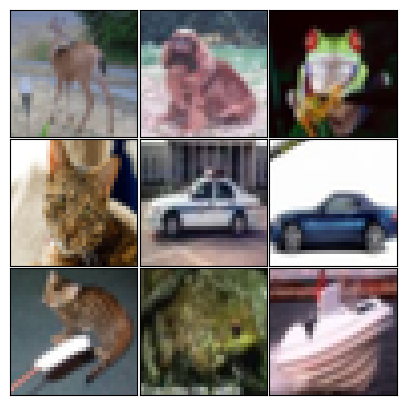

In [33]:
plot_9_images(x_test_scaled[100:100+9])

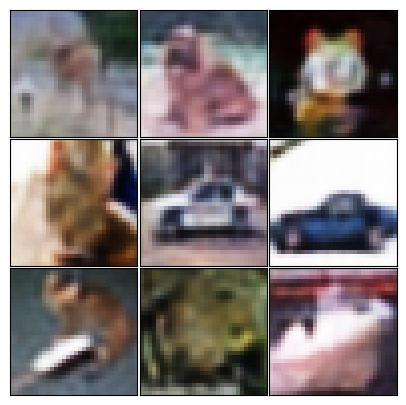

In [34]:
plot_9_images(predictions[100:100+9])